Plt on same plot 

## Importing the BioXTAS API


In [5]:
import bioxtasraw.RAWAPI as raw
import bioxtasraw.RAWPlot as RAWPlot
import bioxtasraw.SASCalc as SASCalc


import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import glob
import os
from pathlib import Path
import re


from pptx import Presentation
from pptx.util import Inches
import tempfile

import imageio.v2 as imageio
import math

from scipy import optimize
from scipy import special



colorWT = 'navy'
colorAA = 'orangered'

Set Up SAXS Settings (from Brookhaven National Laboratory)

In [6]:
my_settings = raw.load_settings('/Applications/raw/docs/source/saxs/images/figure_data/SAXS.cfg')

/opt/anaconda3/envs/RAW/lib/python3.14/site-packages/bioxtasraw/RAWSettings.py:935: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  settings = pickle_obj.load()


# Read .dat files folder and store in dictionary to analyze

In [10]:
def load_profiles_by_frame(folder):
    """
    Load all .dat profiles in a folder into a dictionary keyed by
    the trailing frame number in the filename.

    Example
    -------
    profile_175.dat -> profiles["175"]
    """

    folder = Path(folder)

    profile_paths = sorted(
        folder.glob("*.dat"),
        key=lambda p: int(re.search(r'(\d+)$', p.stem).group(1))
    )

    profile_names = [str(p.resolve()) for p in profile_paths]
    loaded_profiles = raw.load_profiles(profile_names)

    profiles = {}

    for path, profile in zip(profile_paths, loaded_profiles):
        frame = re.search(r'(\d+)$', path.stem).group(1)
        profiles[frame] = profile

    return profiles

In [37]:
# Load profiles into a dictionary keyed by frame number
# Load all .dat files from the WT_092025 folder into a dictionary keyed by frame number
WT_092025_profiles = load_profiles_by_frame("./dat_files/WT_092025")

In [ ]:
# Load profiles into a dictionary keyed by frame number
# Load all .dat files from the AA_052026 folder into a dictionary keyed by frame number
AA_052026_profiles = load_profiles_by_frame("./dat_files/AA_052026")

# Plot profiles in dictionary

### WT Profiles

Text(0, 0.5, 'Intensity (I)')

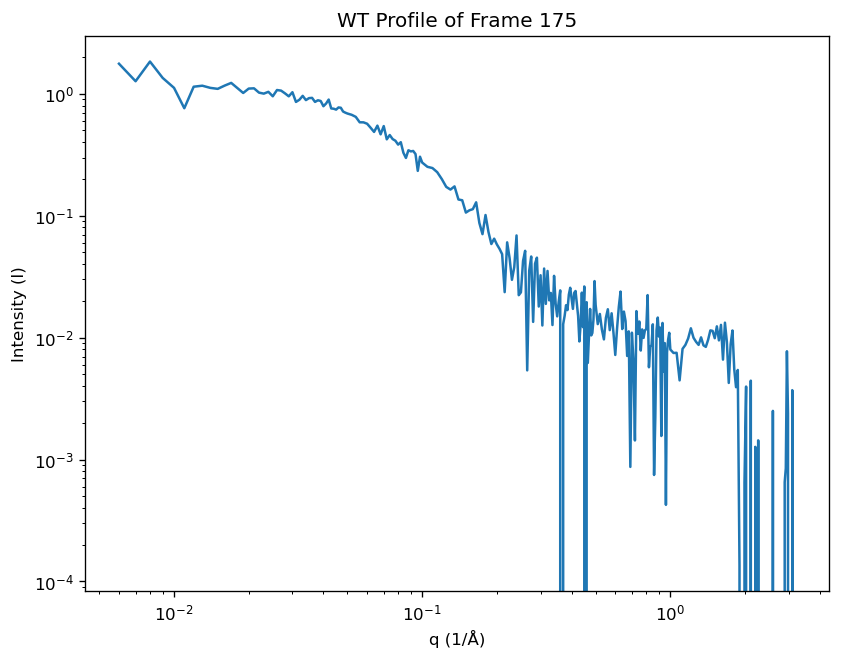

In [97]:
# Example of accessing a specific profile by frame number
frame_number = "175"

profile = WT_092025_profiles[frame_number]
q = profile.getQ()
I = profile.getI()
err = profile.getErr()

plt.figure(figsize=(8,6), dpi=120)
plt.title(f'WT Profile of Frame {frame_number}')
plt.plot(q, I, linestyle='-', marker=None)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')

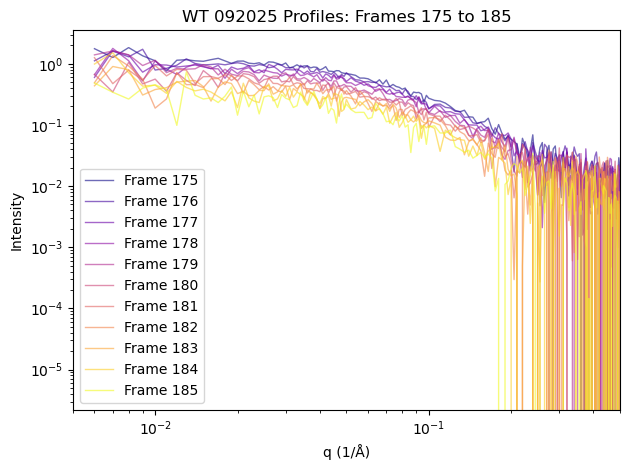

In [19]:
# Plot Sub-profiles

#plt.figure(figsize=(8, 6))
plt.figure()

n = len(WT_092025_profiles)
cmap = plt.cm.plasma  # yellow → purple

for i, (frame, profile) in enumerate(WT_092025_profiles.items()):

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    # Normalize index to [0,1] for colormap
    color = cmap(i / max(1, n - 1))

    plt.plot(
        q,
        intensity,
        color=color,
        alpha=0.6,
        linewidth=1,
        label=f'Frame {frame}'
    )

frame_numbers = list(WT_092025_profiles.keys())
first_frame = frame_numbers[0]
last_frame = frame_numbers[-1]
plt.title(f'WT 092025 Profiles: Frames {first_frame} to {last_frame}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity')
plt.xlim(0.005, 0.5)
plt.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Intensity (I)')

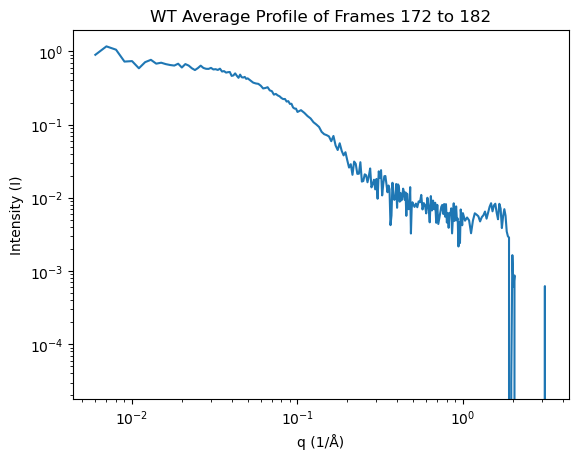

In [44]:
# Take Average of All Profiles in the WT_092025_profiles dictionary
WT_092025_avg_profile = raw.average(list(WT_092025_profiles.values()))

WT_092025_avg_profile
q_avg=WT_092025_avg_profile.getQ()
intensity_avg=WT_092025_avg_profile.getI()
error_avg=WT_092025_avg_profile.getErr()

plt.Figure(figsize=(4,6), dpi=120)
plt.title(f'WT Average Profile of Frames {first_frame} to {last_frame}')
plt.plot(q_avg, intensity_avg, linestyle='-', marker=None)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


### W397A/W433A Profiles

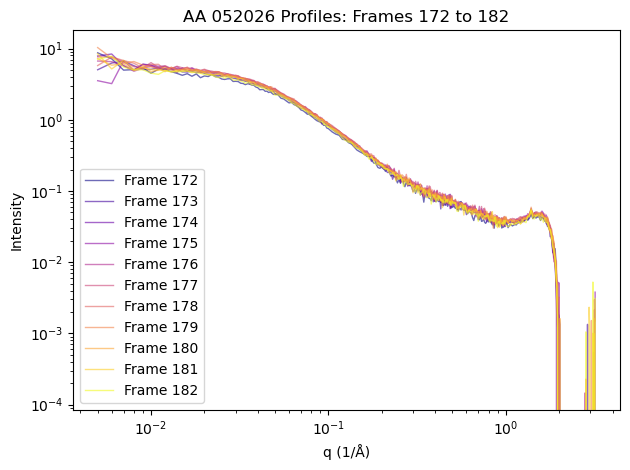

In [40]:
# Plot Sub-profiles

#plt.figure(figsize=(8, 6))
plt.figure()

n = len(AA_052026_profiles)
cmap = plt.cm.plasma  # yellow → purple

for i, (frame, profile) in enumerate(AA_052026_profiles.items()):

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    # Normalize index to [0,1] for colormap
    color = cmap(i / max(1, n - 1))

    plt.plot(
        q,
        intensity,
        color=color,
        alpha=0.6,
        linewidth=1,
        label=f'Frame {frame}'
    )

frame_numbers = list(AA_052026_profiles.keys())
first_frame = frame_numbers[0]
last_frame = frame_numbers[-1]
plt.title(f'AA 052026 Profiles: Frames {first_frame} to {last_frame}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity')
# plt.xlim(0.005, 0.5)
plt.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Intensity (I)')

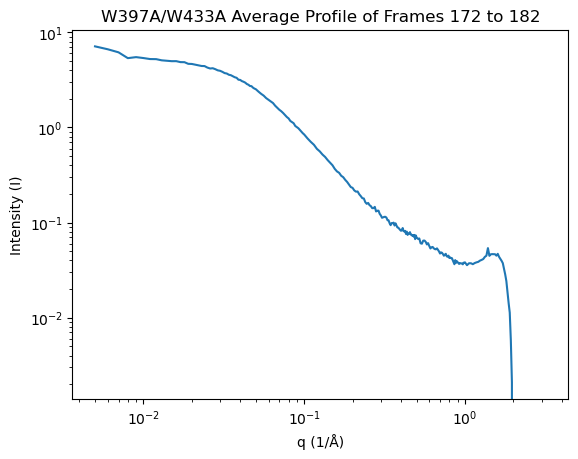

In [45]:
# Take Average of All Profiles in the AA_052026_profiles dictionary
AA_052026_avg_profile = raw.average(list(AA_052026_profiles.values()))

q_avg=AA_052026_avg_profile.getQ()
intensity_avg=AA_052026_avg_profile.getI()
error_avg=AA_052026_avg_profile.getErr()

plt.Figure(figsize=(4,6), dpi=120)
plt.title(f'W397A/W433A Average Profile of Frames {first_frame} to {last_frame}')
plt.plot(q_avg, intensity_avg, linestyle='-', marker=None)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


### Make list of Average Profiles

In [ ]:
avg_profiles = {
    "WT_092025": WT_092025_avg_profile,
    "AA_052026": AA_052026_avg_profile
}

## Scattering Plot of Average Profiles

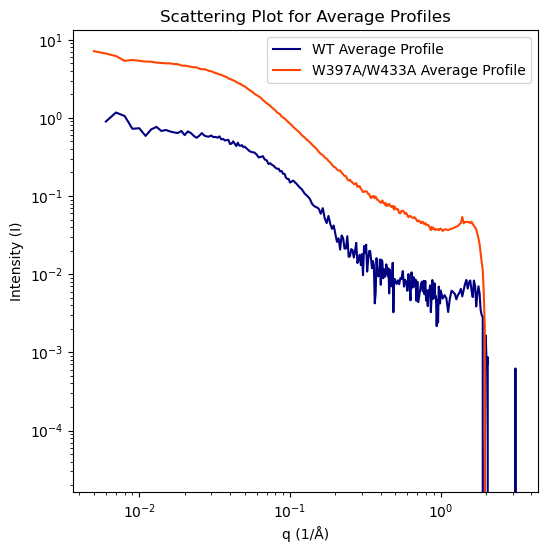

In [128]:
# Scattering Plot for Average Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


plt.title(f'Scattering Plot for Average Profiles')

for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"

    
    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    plt.plot(q, intensity, linestyle='-', 
             marker=None, color=color, label=f'{title}')

    plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.show()


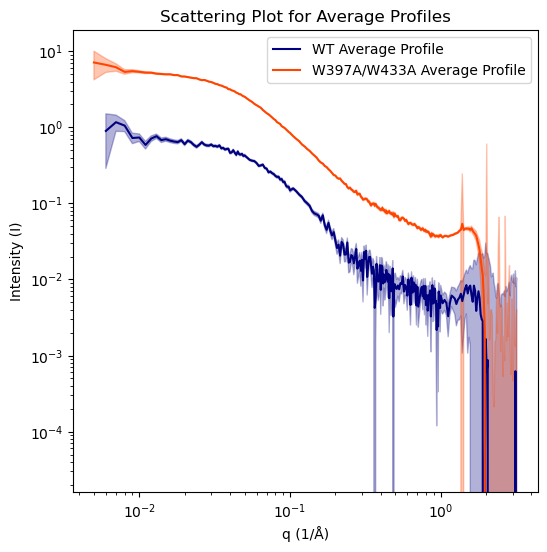

In [131]:
# Scattering Plot for Average Profiles with error bars
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


plt.title(f'Scattering Plot for Average Profiles')

for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"

    
    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    plt.plot(q, intensity, linestyle='-', 
             marker=None, color=color, label=f'{title}')

    plt.fill_between(
    q,
    intensity - error,
    intensity + error,
    alpha=0.3,
    color=color
    )

    plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.show()


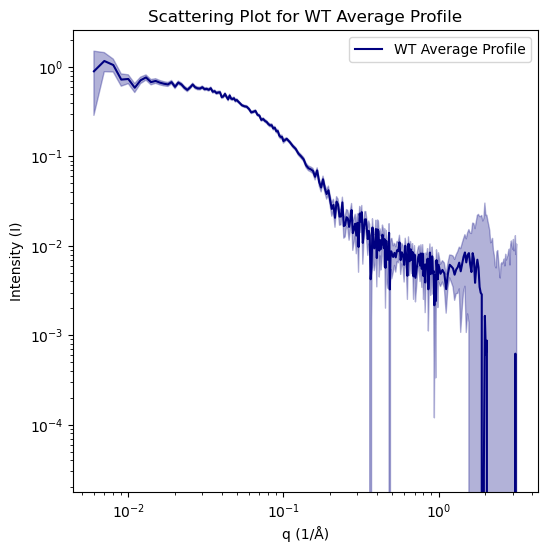

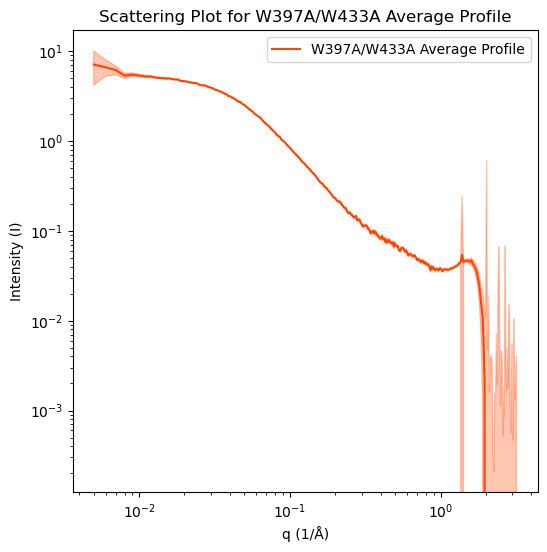

In [159]:
# Scattering Plot for Average Profiles with error bars
for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"

    
    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()
    # Set up plot
    plt.figure(figsize=(6,6))        
    plt.xlabel('q (1/Å)')
    plt.ylabel('Intensity (I)')


    plt.title(f'Scattering Plot for {title}')

    plt.plot(q, intensity, linestyle='-', 
             marker=None, color=color, label=f'{title}')

    plt.fill_between(
    q,
    intensity - error,
    intensity + error,
    alpha=0.3,
    color=color
    )

    plt.legend()

    plt.xscale('log')
    plt.yscale('log')
    plt.show()


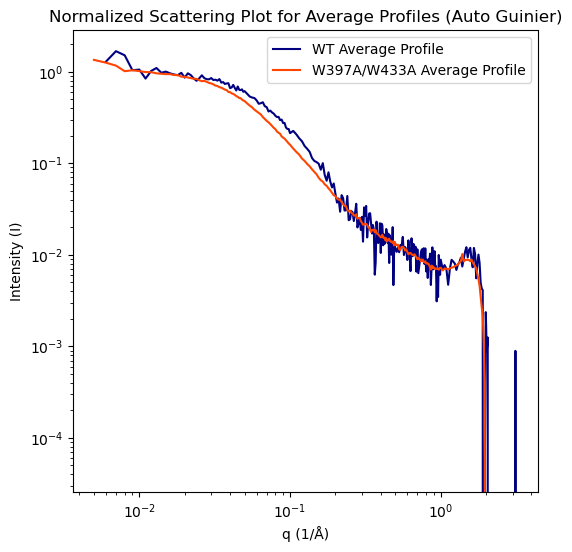

In [129]:
# Scattering Plot for Average Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


plt.title(f'Normalized Scattering Plot for Average Profiles (Auto Guinier)')

for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
        r_sq) = raw.auto_guinier(profile, settings=my_settings)

    
    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    plt.plot(q, intensity/i0, linestyle='-', 
             marker=None, color=color, label=f'{title}')

    plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.show()


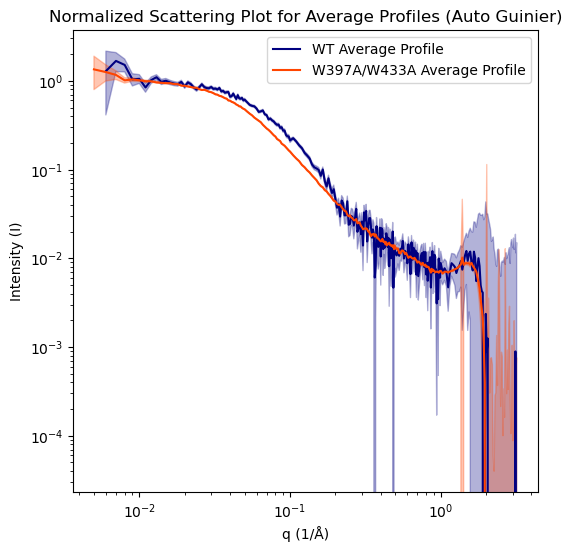

In [134]:
# Scattering Plot for Average Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


plt.title(f'Normalized Scattering Plot for Average Profiles (Auto Guinier)')

for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
        r_sq) = raw.auto_guinier(profile, settings=my_settings)

    
    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    plt.plot(q, intensity/i0, linestyle='-', 
             marker=None, color=color, label=f'{title}')
    
    plt.fill_between(
    q,
    intensity/i0 - error/i0,
    intensity/i0 + error/i0,
    alpha=0.3,
    color=color
    )

    plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.show()


## Guinier Plot of Average Profiles

In [ ]:
def plot_avg_profiles(q, intensity, error, 
                      qmin, qmax, label, color):
    fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

    # Square the q values and take the natural logarithm of the intensity
    q_sq = q**2
    i_ln = np.log(intensity)
    qmin_sq = qmin**2
    qmax_sq = qmax**2

    # plot 0:50 data points for context
    axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o',
            linestyle='None', color='lightgray', label='Data')
    axs[0].set_ylabel('ln(I(q))', fontsize=12)

    # Plot the data points used for the AutoGuinier fit in color
    mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
    axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
                label='Guinier points', color=color, alpha=0.7)

    # Line for the Guinier fit
    # optional: fit a straight line to the selected Guinier points
    if np.count_nonzero(mask) >= 2:
    #Get fit r squared:
        x = np.square(q[idx_min:idx_max+1])
        y = np.log(intensity[idx_min:idx_max+1])
        sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
        
        a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

        y_fit = SASCalc.linear_func(x, a, b)
        y_line= SASCalc.linear_func(q_sq[0:50], a, b)
        
        gui_err = y - y_fit
        residuals = gui_err / sigma  # weighted residuals
        
        # Plot line of best fit
        axs[0].plot(q_sq[0:50], y_line, '-', label=f'Rg={rg:.2f} Å', 
                color=color, alpha=1, linewidth=2.0, zorder=100)
        axs[0].legend()

        
        # Plot residuals in second subplot
        axs[1].plot(x, residuals, marker='o', linestyle='None', color=color, alpha=0.5)
        
        # Set up labels for residuals subplot
        axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
        axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
        axs[1].tick_params(axis='both', labelsize=10)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('q (1/Å)')
    plt.ylabel('Intensity (I)')
    plt.title('Average Profiles Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()

/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_14699/2204597013.py:24: RuntimeWarning: invalid value encountered in log
  i_ln = np.log(intensity)


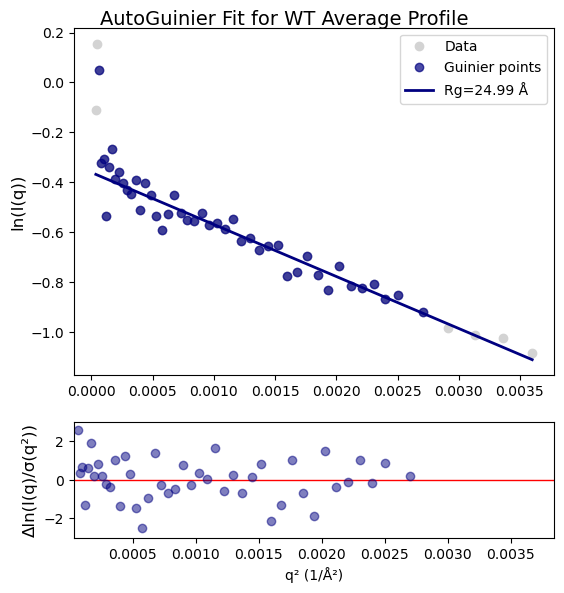

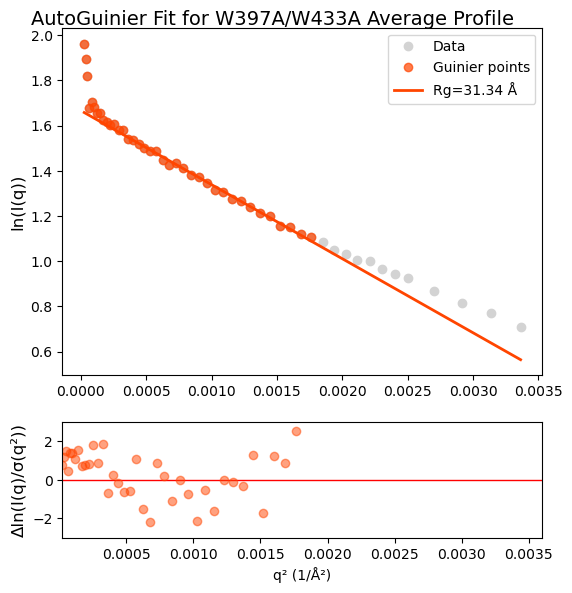

In [55]:
for label, profile in avg_profiles.items():
    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
        r_sq) = raw.auto_guinier(profile, settings=my_settings)

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"

    # Set up the plot
    fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

    # Square the q values and take the natural logarithm of the intensity
    q_sq = q**2
    i_ln = np.log(intensity)
    qmin_sq = qmin**2
    qmax_sq = qmax**2

    # plot 0:50 data points for context
    axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o',
            linestyle='None', color='lightgray', label='Data')
    axs[0].set_ylabel('ln(I(q))', fontsize=12)

    # Plot the AutoGuinier fit data points
    mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
    axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
                label='Guinier points', color=color, alpha=0.7)

    # Line for the Guinier fit
    # optional: fit a straight line to the selected Guinier points
    if np.count_nonzero(mask) >= 2:
    #Get fit r squared:
        x = np.square(q[idx_min:idx_max+1])
        y = np.log(intensity[idx_min:idx_max+1])
        sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
        
        a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

        y_fit = SASCalc.linear_func(x, a, b)
        y_line= SASCalc.linear_func(q_sq[0:50], a, b)
        
        gui_err = y - y_fit
        residuals = gui_err / sigma  # weighted residuals
        
        # Plot line of best fit
        axs[0].plot(q_sq[0:50], y_line, '-', label=f'Rg={rg:.2f} Å', 
                color=color, alpha=1, linewidth=2.0, zorder=100)
        axs[0].legend()

        
        # Plot residuals in second subplot
        axs[1].plot(x, residuals, marker='o', linestyle='None', color=color, alpha=0.5)
        
        # Set up labels for residuals subplot
        axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
        axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
        axs[1].tick_params(axis='both', labelsize=10)
        axs[1].set_xlim(q_sq[0], q_sq[50])  # Set x-axis limits for residuals plot
        axs[1].set_ylim(-3, 3)  # Set y-axis limits for residuals plot

    # Plot Specifications
    plt.xlabel('q² (1/Å²)')
    plt.suptitle(f'AutoGuinier Fit for {title}', fontsize=14)
    plt.show()


/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_14699/2525974637.py:31: RuntimeWarning: invalid value encountered in log
  i_ln = np.log(intensity)


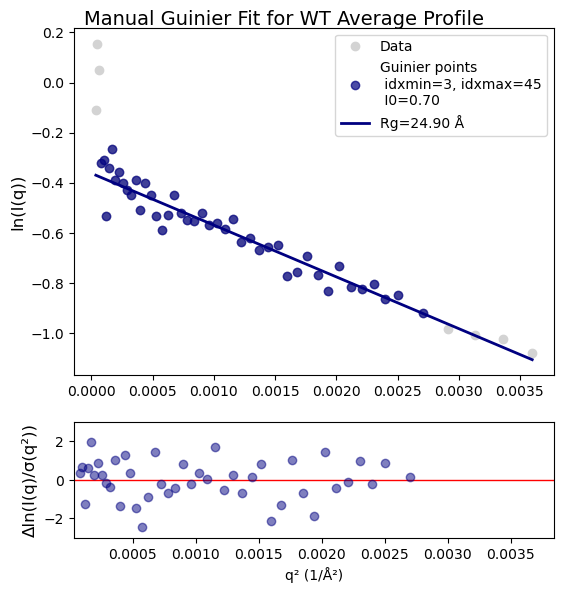

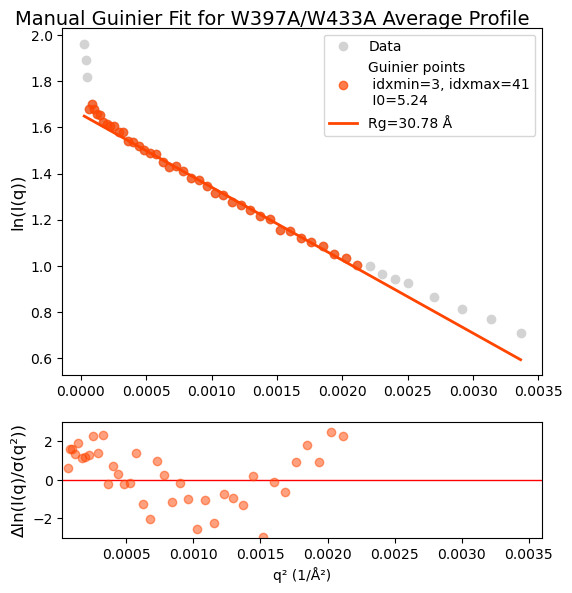

In [87]:
for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
        idx_min = 3
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"
        idx_min = 3
        idx_max = 41

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
        r_sq) = raw.guinier_fit(profile, idx_min,idx_max)
        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()
    # Plot the q and intensity data from first sub-profile as Guinier plot (ln(I) vs q^2)



    # Set up the plot
    fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

    # Square the q values and take the natural logarithm of the intensity
    q_sq = q**2
    i_ln = np.log(intensity)
    qmin_sq = qmin**2
    qmax_sq = qmax**2

    # plot 0:50 data points for context
    axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o',
            linestyle='None', color='lightgray', label='Data')
    axs[0].set_ylabel('ln(I(q))', fontsize=12)

    # Plot the AutoGuinier fit data points
    mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
    axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
                label=f'Guinier points\n idxmin={idx_min}, idxmax={idx_max}\n I0={i0:.2f}', 
                color=color, alpha=0.7)

    # Line for the Guinier fit
    # optional: fit a straight line to the selected Guinier points
    if np.count_nonzero(mask) >= 2:
    #Get fit r squared:
        x = np.square(q[idx_min:idx_max+1])
        y = np.log(intensity[idx_min:idx_max+1])
        sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
        
        a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

        y_fit = SASCalc.linear_func(x, a, b)
        y_line= SASCalc.linear_func(q_sq[0:50], a, b)
        
        gui_err = y - y_fit
        residuals = gui_err / sigma  # weighted residuals
        
        # Plot line of best fit
        axs[0].plot(q_sq[0:50], y_line, '-', label=f'Rg={rg:.2f} Å', 
                color=color, alpha=1, linewidth=2.0, zorder=100)
        axs[0].legend()

        
        # Plot residuals in second subplot
        axs[1].plot(x, residuals, marker='o', linestyle='None', color=color, alpha=0.5)
        
        # Set up labels for residuals subplot
        axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
        axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
        axs[1].tick_params(axis='both', labelsize=10)
        axs[1].set_xlim(q_sq[0], q_sq[50])  # Set x-axis limits for residuals plot
        axs[1].set_ylim(-3, 3)  # Set y-axis limits for residuals plot

    # Plot Specifications
    plt.xlabel('q² (1/Å²)')
    plt.suptitle(f'Manual Guinier Fit for {title}', fontsize=14)
    plt.show()


/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_14699/1593291989.py:29: RuntimeWarning: invalid value encountered in log
  i_ln = np.log(intensity/i0)


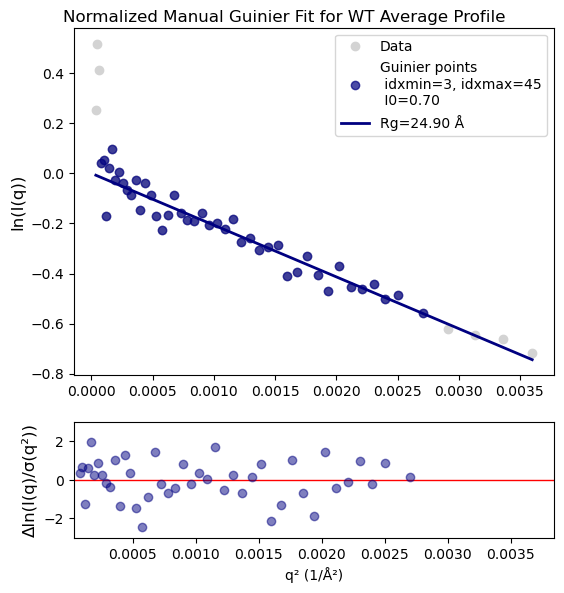

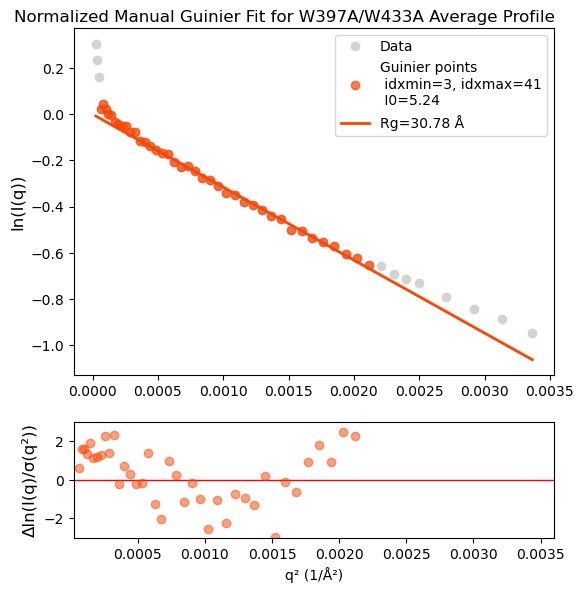

In [95]:
for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
        idx_min = 3
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"
        idx_min = 3
        idx_max = 41

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
        r_sq) = raw.guinier_fit(profile, idx_min,idx_max)
        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()


    # Set up the plot
    fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

    # Square the q values and take the natural logarithm of the intensity
    q_sq = q**2
    i_ln = np.log(intensity/i0)
    qmin_sq = qmin**2
    qmax_sq = qmax**2

    # plot 0:50 data points for context
    axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o',
            linestyle='None', color='lightgray', label='Data')
    axs[0].set_ylabel('ln(I(q))', fontsize=12)

    # Plot the AutoGuinier fit data points
    mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
    axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
                label=f'Guinier points\n idxmin={idx_min}, idxmax={idx_max}\n I0={i0:.2f}', 
                color=color, alpha=0.7)

    # Line for the Guinier fit
    # optional: fit a straight line to the selected Guinier points
    if np.count_nonzero(mask) >= 2:
    #Get fit r squared:
        x = np.square(q[idx_min:idx_max+1])
        y = np.log(intensity[idx_min:idx_max+1]/i0)
        sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
        
        a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

        y_fit = SASCalc.linear_func(x, a, b)
        y_line= SASCalc.linear_func(q_sq[0:50], a, b)
        
        gui_err = y - y_fit
        residuals = gui_err / sigma  # weighted residuals
        
        # Plot line of best fit
        axs[0].plot(q_sq[0:50], y_line, '-', label=f'Rg={rg:.2f} Å', 
                color=color, alpha=1, linewidth=2.0, zorder=100)
        axs[0].legend()

        
        # Plot residuals in second subplot
        axs[1].plot(x, residuals, marker='o', linestyle='None', color=color, alpha=0.5)
        
        # Set up labels for residuals subplot
        axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
        axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
        axs[1].tick_params(axis='both', labelsize=10)
        axs[1].set_xlim(q_sq[0], q_sq[50])  # Set x-axis limits for residuals plot
        axs[1].set_ylim(-3, 3)  # Set y-axis limits for residuals plot

    # Plot Specifications
    plt.xlabel('q² (1/Å²)')
    plt.suptitle(f'Normalized Manual Guinier Fit for {title}')
    plt.show()


In [142]:
class ExtendedGuinier:
    """
    Extended Guinier analysis for SAXS data.

    Parameters
    ----------
    q : array-like
        q values (Å⁻¹)
    intensity : array-like
        Scattering intensity I(q)
    error : array-like, optional
        Experimental uncertainty. Stored for convenience but not used in fitting.
    """

    def __init__(self, q, intensity, error=None):

        self.q = np.asarray(q, dtype=float)
        self.Iq = np.asarray(intensity, dtype=float)

        if error is None:
            self.error = np.ones_like(self.Iq)
        else:
            self.error = np.asarray(error, dtype=float)

    @staticmethod
    def Rg_nu(b, N, nu):
        g = 1.1615
        return np.sqrt(
            g * (g + 1)
            / (2 * (g + 2 * nu) * (g + 2 * nu + 1))
        ) * b * N**nu

    @staticmethod
    def chisq_extguin(parms, q, log_Iq, Nres, b):

        nu = parms[0]
        log_I0 = parms[1]

        Rg = ExtendedGuinier.Rg_nu(b, Nres, nu)

        log_Iq_fit = (
            log_I0
            - q**2 * Rg**2 / 3
            + 0.0479 * (nu - 0.212) * q**4 * Rg**4
        )

        dI = log_Iq_fit - log_Iq

        return np.dot(dI, dI)

    def analyze(
        self,
        Nres,
        b_Angstrom=5.5,
        nu_init=0.5,
        qcut=None,
        q_start_index=0,
    ):

        q = self.q
        Iq = self.Iq

        valid = np.isfinite(q) & np.isfinite(Iq) & (Iq > 0)

        q = q[valid]
        Iq = Iq[valid]

        if len(q) == 0:
            return None

        if qcut is None:
            Rg_init = self.Rg_nu(b_Angstrom, Nres, 0.6)
            qcut = 2.0 / Rg_init

        mask = (q >= q[q_start_index]) & (q <= qcut)

        qrange = q[mask]
        log_Iq = np.log(Iq[mask])

        if len(qrange) < 3:
            raise ValueError("Not enough points in Guinier region.")

        log_I0_init = log_Iq[0]

        opt_parm = optimize.fmin(
            self.chisq_extguin,
            [nu_init, log_I0_init],
            args=(qrange, log_Iq, Nres, b_Angstrom),
            disp=False,
        )

        nu_final, log_I0_final = opt_parm

        Rg_final = self.Rg_nu(
            b_Angstrom,
            Nres,
            nu_final,
        )

        log_Iq_fit = (
            log_I0_final
            - qrange**2 * Rg_final**2 / 3
            + 0.0479
            * (nu_final - 0.212)
            * qrange**4
            * Rg_final**4
        )

        return {
            "nu": nu_final,
            "Rg": Rg_final,
            "I0": np.exp(log_I0_final),
            "log_I0": log_I0_final,
            "q": qrange,
            "q_squared": qrange**2,
            "log_Iq": log_Iq,
            "log_Iq_fit": log_Iq_fit,
            "residuals": log_Iq_fit - log_Iq,
        }

/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_14699/3700978011.py:36: RuntimeWarning: invalid value encountered in log
  I_ln = np.log(intensity)


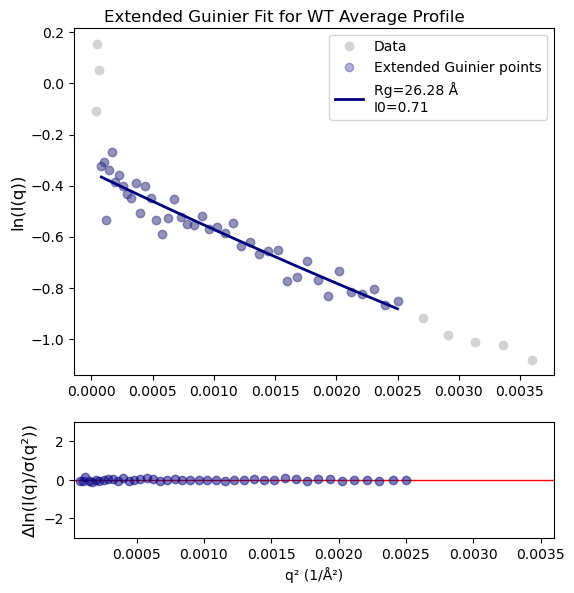

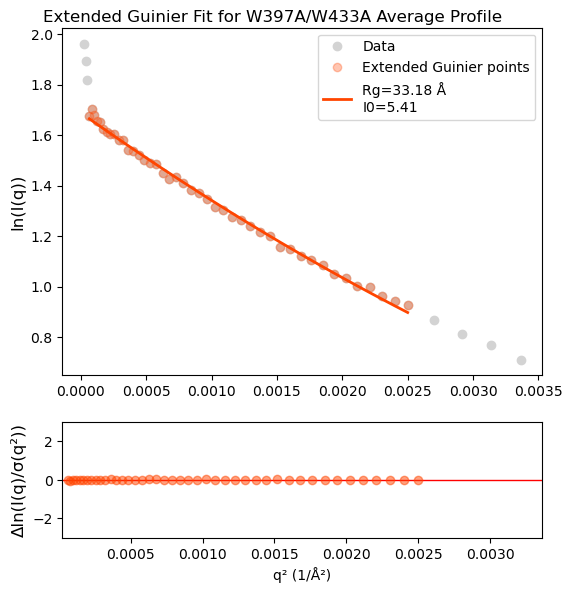

In [156]:
# Extended Guinier Analysis for Average Profiles
for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
        idx_min = 3
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"
        idx_min = 3
        idx_max = 41

    
    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    eg = ExtendedGuinier(q, intensity, error)
    result = eg.analyze(Nres=121, q_start_index=idx_min, b_Angstrom=5.5)

    qrange = result["q"]
    log_Iq = result["log_Iq"]
    log_Iq_fit = result["log_Iq_fit"]
    residuals = result ["residuals"]
    I0 = result["I0"]


    # Set up the plot
    fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

    # Square the q values and take the natural logarithm of the intensity
    q_sq = q ** 2
    I_ln = np.log(intensity)

    # plot the data points for context
    max_q = len(qrange)

    start_idx = 0
    end_idx = max_q

    mask = np.zeros(len(q), dtype=bool)
    mask[max(0, start_idx-1):min(len(q), 50)] = True

    axs[0].plot(q_sq[mask], I_ln[mask], marker='o',
         linestyle='None', color='lightgray', label='Data')
    axs[0].set_ylabel('ln(I(q))', fontsize=12)

    # Plot the ExtendedGuinier fit data points
    axs[0].plot(qrange**2, log_Iq, marker='o', linestyle='None',
                label='Extended Guinier points', color=color, alpha=0.3)
    axs[0].plot(qrange**2, log_Iq_fit, linestyle='-', 
                color=color,
                label=f'Rg={result["Rg"]:.2f} Å\nI0={I0:.2f}',
                alpha=1, linewidth=2.0, zorder=100)
    axs[0].legend()

    
    # Plot residuals in second subplot
    axs[1].plot(qrange**2, residuals, marker='o', linestyle='None', color=color, alpha=0.5)
    
    # Set up labels for residuals subplot
    axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
    axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
    axs[1].tick_params(axis='both', labelsize=10)
    axs[1].set_xlim(q_sq[0], q_sq[mask].max())  # Set x-axis limits for residuals plot
    axs[1].set_ylim(-3, 3)  # Set y-axis limits for residuals plot

    # Plot Specifications
    plt.xlabel('q² (1/Å²)')
    plt.suptitle(f'Extended Guinier Fit for {title}')
    plt.show()


## Dimensionless Kratky Plots of Average Profiles


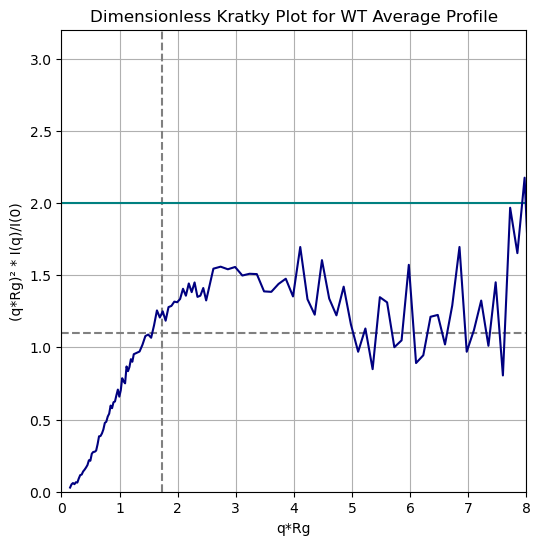

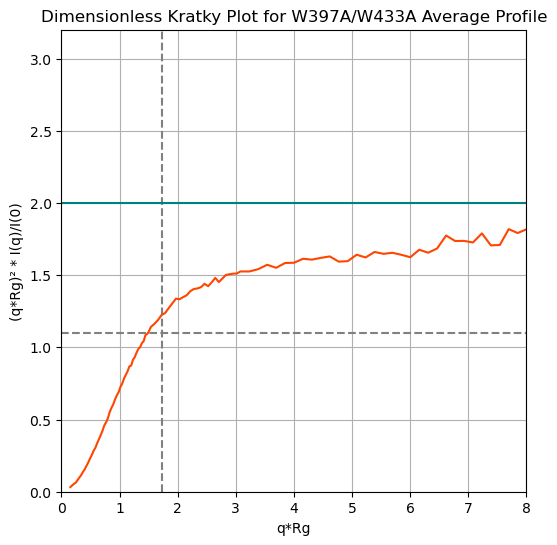

In [58]:
# Dimensionless Kratky Plot for Average Profiles
for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
        idx_min = 3
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"
        idx_min = 3
        idx_max = 41

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
        r_sq) = raw.guinier_fit(profile, idx_min,idx_max)
        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()
    # Plot the q and intensity data from first sub-profile as Guinier plot (ln(I) vs q^2)

    # Calculate Kratky parameters
    xkrat = q * rg 
    ykrat = (xkrat ** 2 * intensity) / i0  # (q*rg)^2 * intensity / i0

    # Set up plot
    plt.figure(figsize=(6,6))        
    plt.xlabel('q*Rg')
    plt.ylabel('(q*Rg)² * I(q)/I(0)')

    plt.axvline(x=1.73, color='grey', linestyle='--')
    plt.axhline(y=1.1, color='grey', linestyle='--', label='1.1')
    plt.axhline(y=2, color='teal', linestyle='-') 
    plt.grid(True)
    plt.xlim(0, 8)
    plt.ylim(0, 3.2) 

    # Plot Kratky curve
    plt.plot(xkrat, ykrat, linestyle='-', color=color, label='Kratky plot')
    plt.title(f'Dimensionless Kratky Plot for {title}')

    plt.show()


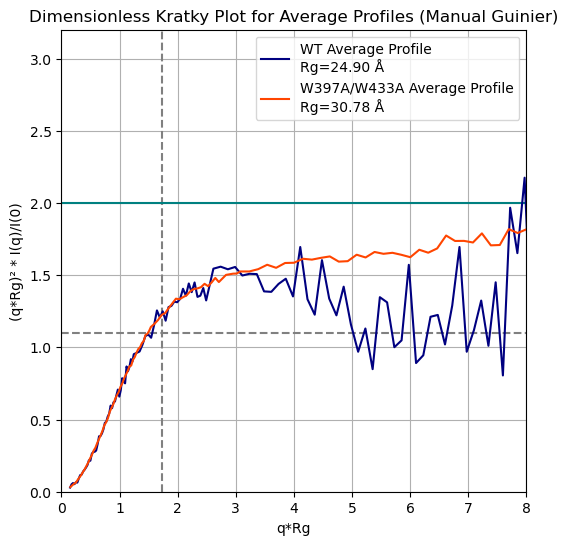

In [72]:
# Dimensionless Kratky Plot for Average Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q*Rg')
plt.ylabel('(q*Rg)² * I(q)/I(0)')

plt.axvline(x=1.73, color='grey', linestyle='--')
plt.axhline(y=1.1, color='grey', linestyle='--')
plt.axhline(y=2, color='teal', linestyle='-') 
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 3.2) 
plt.title(f'Dimensionless Kratky Plot for Average Profiles (Manual Guinier)')

for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
        idx_min = 3
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"
        idx_min = 3
        idx_max = 41

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
        r_sq) = raw.guinier_fit(profile, idx_min,idx_max)
        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()
    # Plot the q and intensity data from first sub-profile as Guinier plot (ln(I) vs q^2)

    # Calculate Kratky parameters
    xkrat = q * rg 
    ykrat = (xkrat ** 2 * intensity) / i0  # (q*rg)^2 * intensity / i0


    # Plot Kratky curve
    plt.plot(xkrat, ykrat, linestyle='-', color=color, label=f'{title}\nRg={rg:.2f} Å')
    plt.legend()


plt.show()


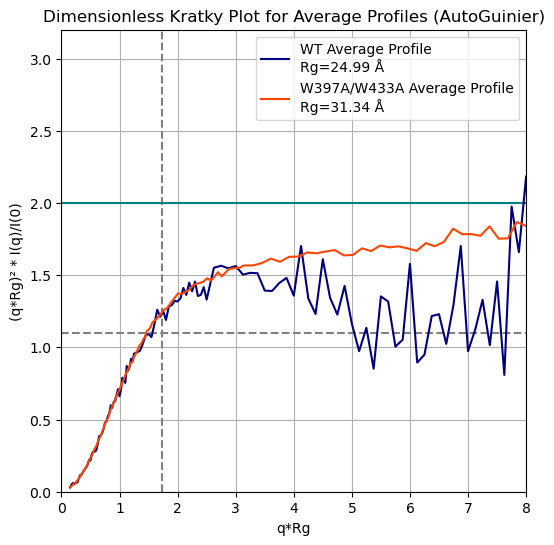

In [70]:
# Dimensionless Kratky Plot for Average Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q*Rg')
plt.ylabel('(q*Rg)² * I(q)/I(0)')

plt.axvline(x=1.73, color='grey', linestyle='--')
plt.axhline(y=1.1, color='grey', linestyle='--')
plt.axhline(y=2, color='teal', linestyle='-') 
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 3.2) 
plt.title(f'Dimensionless Kratky Plot for Average Profiles (AutoGuinier)')

for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
        idx_min = 3
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"
        idx_min = 3
        idx_max = 41

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
        r_sq) = raw.auto_guinier(profile, settings=my_settings)

        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()
    # Plot the q and intensity data from first sub-profile as Guinier plot (ln(I) vs q^2)

    # Calculate Kratky parameters
    xkrat = q * rg 
    ykrat = (xkrat ** 2 * intensity) / i0  # (q*rg)^2 * intensity / i0


    # Plot Kratky curve
    plt.plot(xkrat, ykrat, linestyle='-', color=color, label=f'{title}\nRg={rg:.2f} Å')
    plt.legend()


plt.show()


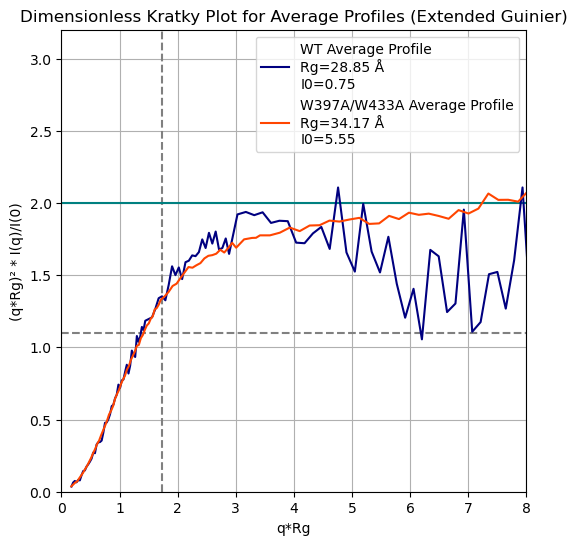

In [153]:
# Dimensionless Kratky Plot for Average Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q*Rg')
plt.ylabel('(q*Rg)² * I(q)/I(0)')

plt.axvline(x=1.73, color='grey', linestyle='--')
plt.axhline(y=1.1, color='grey', linestyle='--')
plt.axhline(y=2, color='teal', linestyle='-') 
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 3.2) 
plt.title(f'Dimensionless Kratky Plot for Average Profiles (Extended Guinier)')

for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    eg = ExtendedGuinier(q, intensity, error)
    result = eg.analyze(Nres=121, q_start_index=1)
    rg=result["Rg"]
    i0 = result["I0"]

    # Calculate Kratky parameters
    xkrat = q * rg 
    ykrat = (xkrat ** 2 * intensity) / i0  # (q*rg)^2 * intensity / i0


    # Plot Kratky curve
    plt.plot(xkrat, ykrat, linestyle='-', color=color, label=f'{title}\nRg={rg:.2f} Å\nI0={i0:.2f}')
    plt.legend()


plt.show()


## P(r) Function and Plot of Average Profiles

Auto-determined Dmax for WT Average Profile: 91.00 Å
GNOM fit results for Dmax=91 Å:
Dmax: 91.00 Å
Rg: 27.300 ± 0.592 Å
i0: 0.714


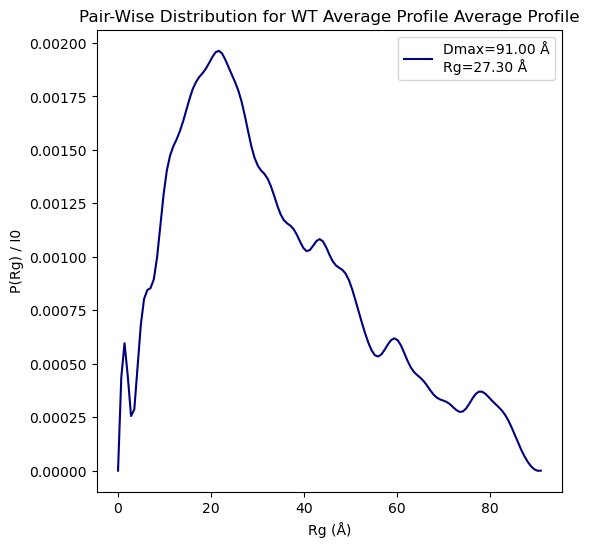

Auto-determined Dmax for W397A/W433A Average Profile: 114.00 Å
GNOM fit results for Dmax=114 Å:
Dmax: 114.00 Å
Rg: 32.680 ± 0.228 Å
i0: 5.317


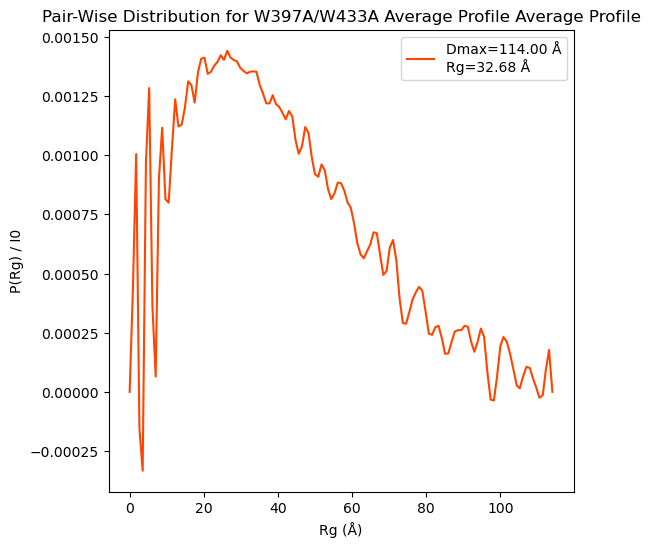

In [ ]:
# GNOM Analysis for Average Profiles
for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
        idx_min = 3
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"
        idx_min = 3
        idx_max = 41

    dmax = raw.auto_dmax(profile)
    print(f"Auto-determined Dmax for {title}: {dmax:.2f} Å")

    (gnom_ift, gnom_dmax, gnom_rg, gnom_i0, gnom_rg_err,
    gnom_i0_err, gnom_total_est, gnom_chi_sq, gnom_alpha,
    gnom_quality) = raw.gnom(profile, dmax)

    print(f"GNOM fit results for Dmax={dmax} Å:")
    print(f"Dmax: {gnom_dmax:.2f} Å")
    print(f"Rg: {gnom_rg:.3f} ± {gnom_rg_err:.3f} Å")


    iftm = gnom_ift

    i0 = float(iftm.getParameter('i0'))
    print(f"i0: {i0:.3f}")

    # Set up plot
    plt.figure(figsize=(6,6))        
    plt.xlabel('Rg (Å)')
    plt.ylabel('P(Rg) / I0')

    plt.plot(iftm.r, iftm.p/i0, color=color, label=f'Dmax={dmax:.2f} Å\nRg={gnom_rg:.2f} Å')
    plt.legend()


    # Plot Pair-Wise Distribution
    plt.title(f'Pair-Wise Distribution for {title}')

    plt.show()


GNOM fit results for Dmax=95 Å:
Dmax: 95.00 Å
Rg: 27.320 ± 0.589 Å
i0: 0.714


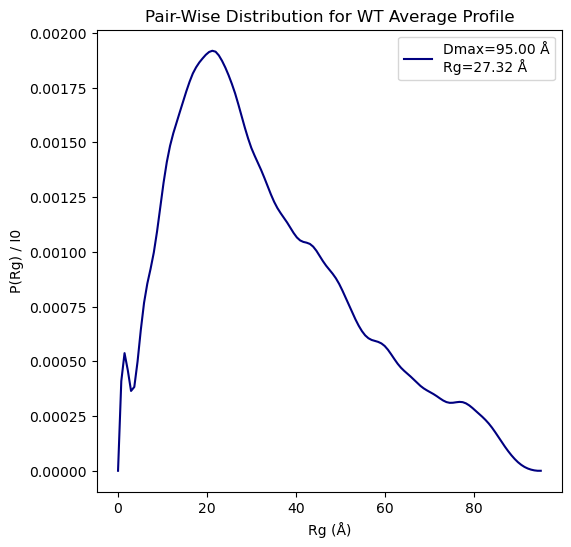

GNOM fit results for Dmax=139 Å:
Dmax: 139.00 Å
Rg: 34.230 ± 0.301 Å
i0: 5.427


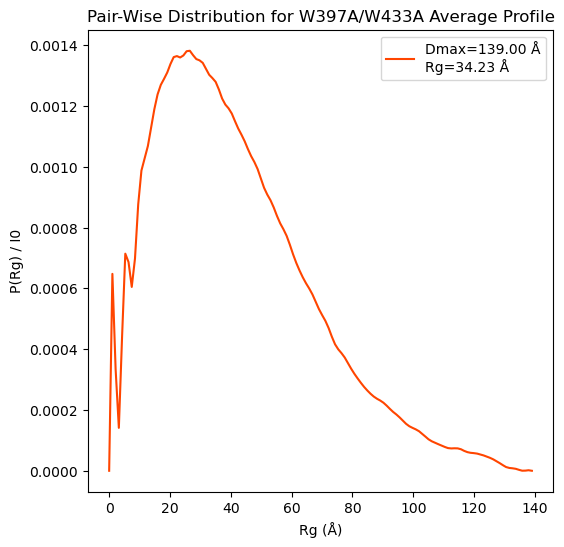

In [160]:
# GNOM Analysis for Average Profiles
for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT Average Profile"
        dmax = 95
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A Average Profile"
        dmax = 139


    (gnom_ift, gnom_dmax, gnom_rg, gnom_i0, gnom_rg_err,
    gnom_i0_err, gnom_total_est, gnom_chi_sq, gnom_alpha,
    gnom_quality) = raw.gnom(profile, dmax)

    print(f"GNOM fit results for Dmax={dmax} Å:")
    print(f"Dmax: {gnom_dmax:.2f} Å")
    print(f"Rg: {gnom_rg:.3f} ± {gnom_rg_err:.3f} Å")

    iftm = gnom_ift

    i0 = float(iftm.getParameter('i0'))
    print(f"i0: {i0:.3f}")

    # Set up plot
    plt.figure(figsize=(6,6))        
    plt.xlabel('Rg (Å)')
    plt.ylabel('P(Rg) / I0')

    plt.plot(iftm.r, iftm.p/i0, color=color, label=f'Dmax={dmax:.2f} Å\nRg={gnom_rg:.2f} Å')
    # plt.axvline(x=gnom_rg, color=color, linestyle='--')
    plt.legend()


    # Plot Pair-Wise Distribution
    plt.title(f'Pair-Wise Distribution for {title}')

    plt.show()


GNOM fit results for Dmax=95 Å:
Dmax: 95.00 Å
Rg: 27.300 ± 0.555 Å
gnom_chi_sq: 0.679
i0: 0.714
GNOM fit results for Dmax=139 Å:
Dmax: 139.00 Å
Rg: 34.230 ± 0.340 Å
gnom_chi_sq: 2.424
i0: 5.427


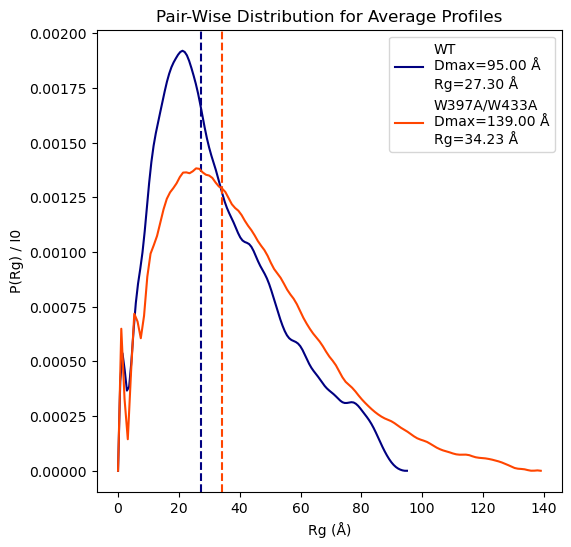

In [85]:
plt.figure(figsize=(6,6))        
plt.xlabel('Rg (Å)')
plt.ylabel('P(Rg) / I0')

# Dimensionless Kratky Plot for Average Profiles
for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT"
        dmax = 95
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A"
        dmax = 139


    (gnom_ift, gnom_dmax, gnom_rg, gnom_i0, gnom_rg_err,
    gnom_i0_err, gnom_total_est, gnom_chi_sq, gnom_alpha,
    gnom_quality) = raw.gnom(profile, dmax)

    print(f"GNOM fit results for Dmax={dmax} Å:")
    print(f"Dmax: {gnom_dmax:.2f} Å")
    print(f"Rg: {gnom_rg:.3f} ± {gnom_rg_err:.3f} Å")
    # print(f"gnom_quality: {gnom_quality}")
    print(f"gnom_chi_sq: {gnom_chi_sq:.3f}")

    iftm = gnom_ift

    i0 = float(iftm.getParameter('i0'))
    print(f"i0: {i0:.3f}")

    # Set up plot


    plt.plot(iftm.r, iftm.p/i0, color=color, 
             label=f'{title}\nDmax={dmax:.2f} Å\nRg={gnom_rg:.2f} Å')
    plt.axvline(x=gnom_rg, color=color, linestyle='--')

    


    # Plot Pair-Wise Distribution
plt.title(f'Pair-Wise Distribution for Average Profiles')
plt.legend()
plt.show()


GNOM fit results for Dmax=95 Å:
Dmax: 95.00 Å
Rg: 27.300 ± 0.646 Å
gnom_chi_sq: 0.679
i0: 0.714
GNOM fit results for Dmax=139 Å:
Dmax: 139.00 Å
Rg: 34.230 ± 0.280 Å
gnom_chi_sq: 2.424
i0: 5.427


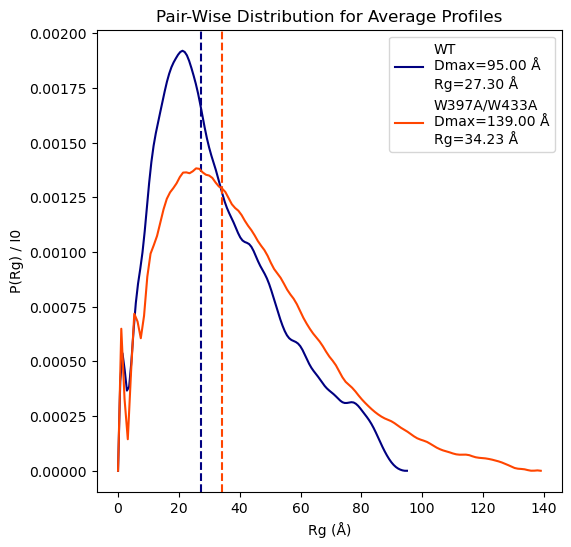

In [86]:
plt.figure(figsize=(6,6))        
plt.xlabel('Rg (Å)')
plt.ylabel('P(Rg) / I0')

# Dimensionless Kratky Plot for Average Profiles
for label, profile in avg_profiles.items():
    if label == "WT_092025":
        color = colorWT
        title = "WT"
        idx_min = 3
        idx_max = 45
        dmax = 95
    elif label == "AA_052026":
        color = colorAA
        title = "W397A/W433A"
        idx_min = 3
        idx_max = 41
        dmax = 139


    (gnom_ift, gnom_dmax, gnom_rg, gnom_i0, gnom_rg_err,
    gnom_i0_err, gnom_total_est, gnom_chi_sq, gnom_alpha,
    gnom_quality) = raw.gnom(profile, dmax, idx_min=idx_min)

    print(f"GNOM fit results for Dmax={dmax} Å:")
    print(f"Dmax: {gnom_dmax:.2f} Å")
    print(f"Rg: {gnom_rg:.3f} ± {gnom_rg_err:.3f} Å")
    # print(f"gnom_quality: {gnom_quality}")
    print(f"gnom_chi_sq: {gnom_chi_sq:.3f}")

    iftm = gnom_ift

    i0 = float(iftm.getParameter('i0'))
    print(f"i0: {i0:.3f}")

    # Set up plot


    plt.plot(iftm.r, iftm.p/i0, color=color, 
             label=f'{title}\nDmax={dmax:.2f} Å\nRg={gnom_rg:.2f} Å')
    plt.axvline(x=gnom_rg, color=color, linestyle='--')

    


    # Plot Pair-Wise Distribution
plt.title(f'Pair-Wise Distribution for Average Profiles')
plt.legend()
plt.show()


# Individual Profiles of Interest

In [112]:
WT_frame_number = "180"
AA_frame_number = "178"

profiles_of_interest = {"WT_092025": WT_092025_profiles[WT_frame_number],
                         "AA_052026": AA_052026_profiles[AA_frame_number]}

## Scattering Plot of Individual Profiles

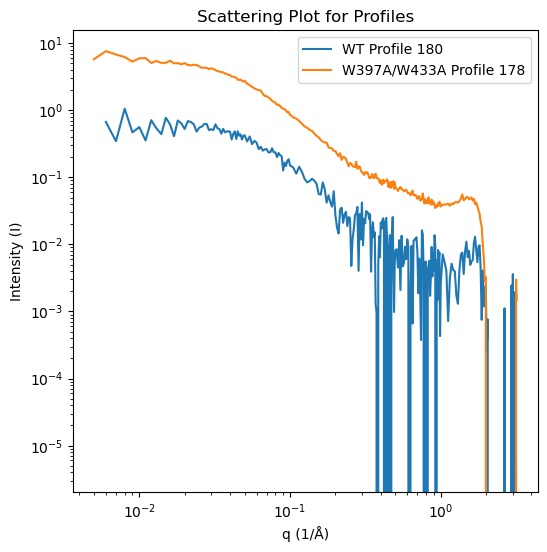

In [105]:
# Scattering Plot for Average Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


plt.title(f'Scattering Plot for Profiles')

for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"

    
    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    # Calculate Kratky parameters
    plt.plot(q, intensity, linestyle='-', 
             marker=None, label=f'{title}')

    plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.show()


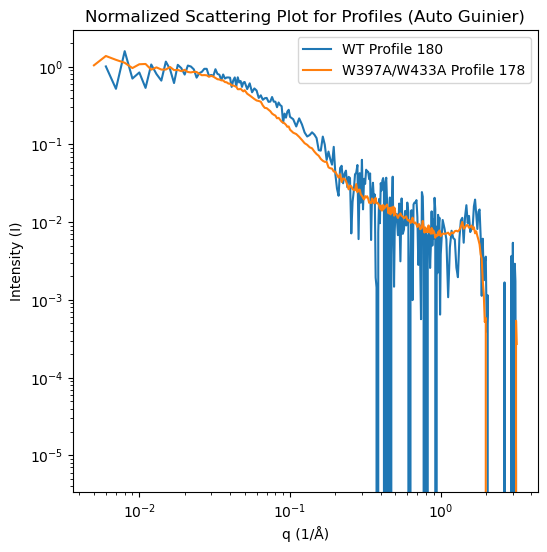

In [106]:
# Scattering Plot for Average Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q (1/Å)')
plt.ylabel('Intensity (I)')


plt.title(f'Normalized Scattering Plot for Profiles (Auto Guinier)')

for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
        r_sq) = raw.auto_guinier(profile, settings=my_settings)

    
    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    # Calculate Kratky parameters
    plt.plot(q, intensity/i0, linestyle='-', 
             marker=None, label=f'{title}')

    plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.show()


## Guinier Plot of Individual Profiles

/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_14699/2905351265.py:23: RuntimeWarning: invalid value encountered in log
  i_ln = np.log(intensity)


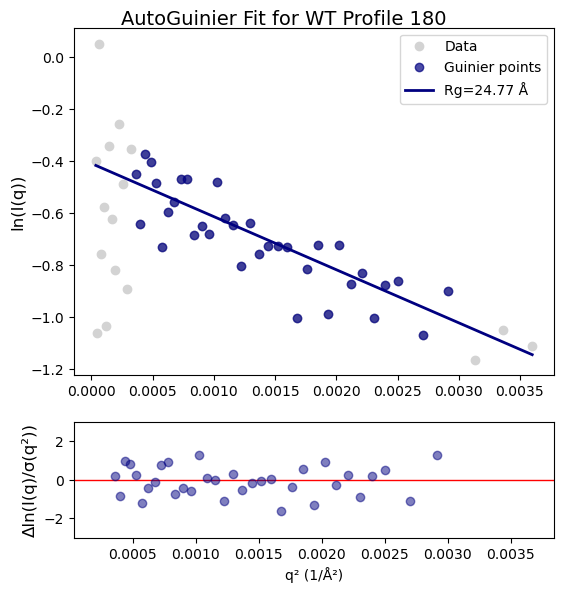

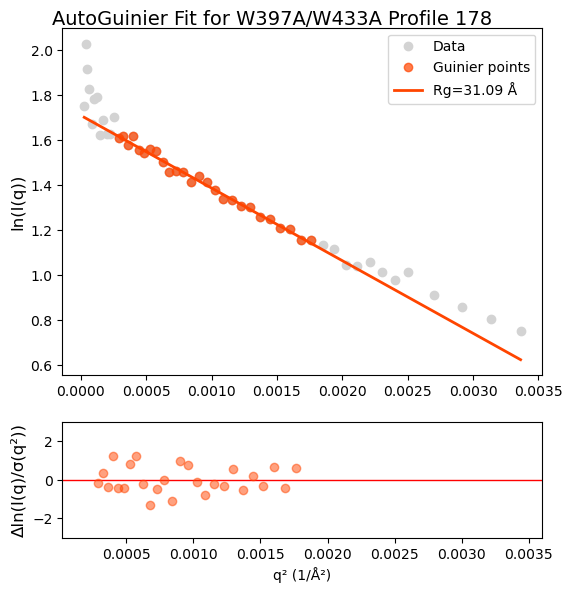

In [107]:
# Auto Guinier for Individual Profiles
for label, profile in profiles_of_interest.items():
    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
        r_sq) = raw.auto_guinier(profile, settings=my_settings)

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()

    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"

    # Set up the plot
    fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

    # Square the q values and take the natural logarithm of the intensity
    q_sq = q**2
    i_ln = np.log(intensity)
    qmin_sq = qmin**2
    qmax_sq = qmax**2

    # plot 0:50 data points for context
    axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o',
            linestyle='None', color='lightgray', label='Data')
    axs[0].set_ylabel('ln(I(q))', fontsize=12)

    # Plot the AutoGuinier fit data points
    mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
    axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
                label='Guinier points', color=color, alpha=0.7)

    # Line for the Guinier fit
    # optional: fit a straight line to the selected Guinier points
    if np.count_nonzero(mask) >= 2:
    #Get fit r squared:
        x = np.square(q[idx_min:idx_max+1])
        y = np.log(intensity[idx_min:idx_max+1])
        sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
        
        a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

        y_fit = SASCalc.linear_func(x, a, b)
        y_line= SASCalc.linear_func(q_sq[0:50], a, b)
        
        gui_err = y - y_fit
        residuals = gui_err / sigma  # weighted residuals
        
        # Plot line of best fit
        axs[0].plot(q_sq[0:50], y_line, '-', label=f'Rg={rg:.2f} Å', 
                color=color, alpha=1, linewidth=2.0, zorder=100)
        axs[0].legend()

        
        # Plot residuals in second subplot
        axs[1].plot(x, residuals, marker='o', linestyle='None', color=color, alpha=0.5)
        
        # Set up labels for residuals subplot
        axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
        axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
        axs[1].tick_params(axis='both', labelsize=10)
        axs[1].set_xlim(q_sq[0], q_sq[50])  # Set x-axis limits for residuals plot
        axs[1].set_ylim(-3, 3)  # Set y-axis limits for residuals plot

    # Plot Specifications
    plt.xlabel('q² (1/Å²)')
    plt.suptitle(f'AutoGuinier Fit for {title}', fontsize=14)
    plt.show()


/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_14699/275089071.py:29: RuntimeWarning: invalid value encountered in log
  i_ln = np.log(intensity)


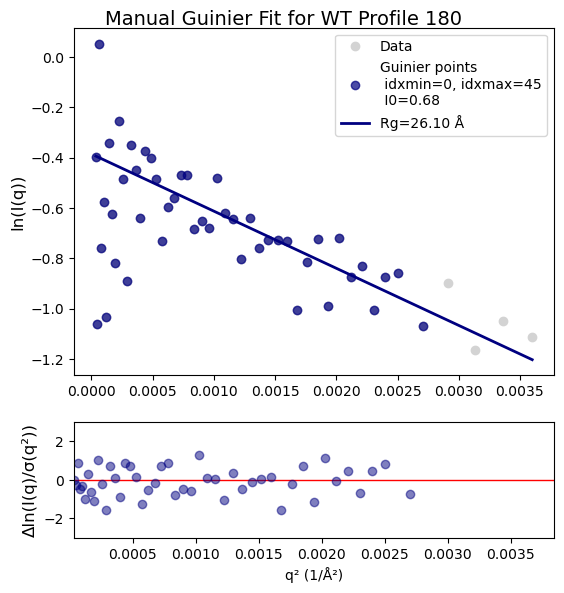

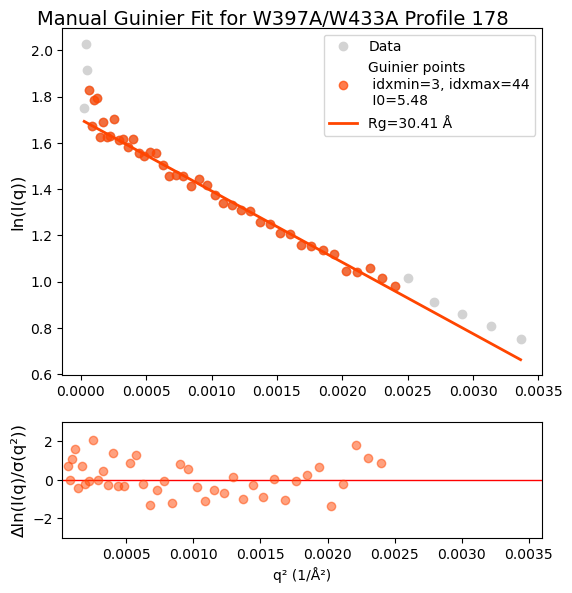

In [109]:
# Guinier Fit for Profiles of Interest
for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
        idx_min = 0
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"
        idx_min = 3
        idx_max = 44

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
        r_sq) = raw.guinier_fit(profile, idx_min,idx_max)
        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()


    # Set up the plot
    fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

    # Square the q values and take the natural logarithm of the intensity
    q_sq = q**2
    i_ln = np.log(intensity)
    qmin_sq = qmin**2
    qmax_sq = qmax**2

    # plot 0:50 data points for context
    axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o',
            linestyle='None', color='lightgray', label='Data')
    axs[0].set_ylabel('ln(I(q))', fontsize=12)

    # Plot the AutoGuinier fit data points
    mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
    axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
                label=f'Guinier points\n idxmin={idx_min}, idxmax={idx_max}\n I0={i0:.2f}', 
                color=color, alpha=0.7)

    # Line for the Guinier fit
    # optional: fit a straight line to the selected Guinier points
    if np.count_nonzero(mask) >= 2:
    #Get fit r squared:
        x = np.square(q[idx_min:idx_max+1])
        y = np.log(intensity[idx_min:idx_max+1])
        sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
        
        a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

        y_fit = SASCalc.linear_func(x, a, b)
        y_line= SASCalc.linear_func(q_sq[0:50], a, b)
        
        gui_err = y - y_fit
        residuals = gui_err / sigma  # weighted residuals
        
        # Plot line of best fit
        axs[0].plot(q_sq[0:50], y_line, '-', label=f'Rg={rg:.2f} Å', 
                color=color, alpha=1, linewidth=2.0, zorder=100)
        axs[0].legend()

        
        # Plot residuals in second subplot
        axs[1].plot(x, residuals, marker='o', linestyle='None', color=color, alpha=0.5)
        
        # Set up labels for residuals subplot
        axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
        axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
        axs[1].tick_params(axis='both', labelsize=10)
        axs[1].set_xlim(q_sq[0], q_sq[50])  # Set x-axis limits for residuals plot
        axs[1].set_ylim(-3, 3)  # Set y-axis limits for residuals plot

    # Plot Specifications
    plt.xlabel('q² (1/Å²)')
    plt.suptitle(f'Manual Guinier Fit for {title}', fontsize=14)
    plt.show()


/var/folders/pd/1zdq_nrd781b0d2ptzzg9_tr0000gp/T/ipykernel_14699/3297489361.py:30: RuntimeWarning: invalid value encountered in log
  i_ln = np.log(intensity/i0)


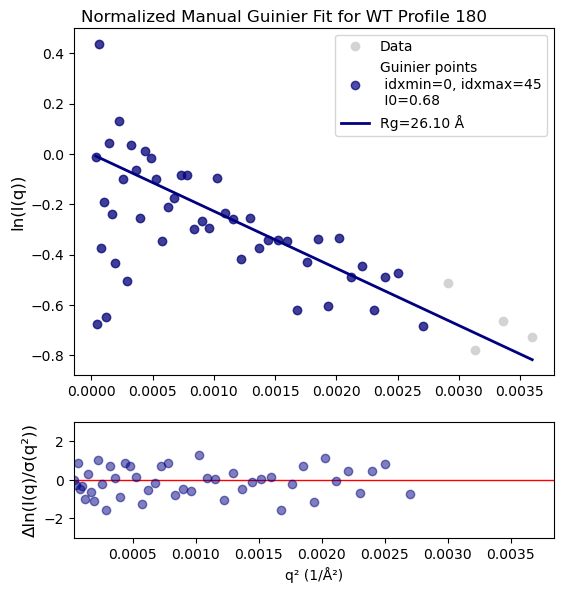

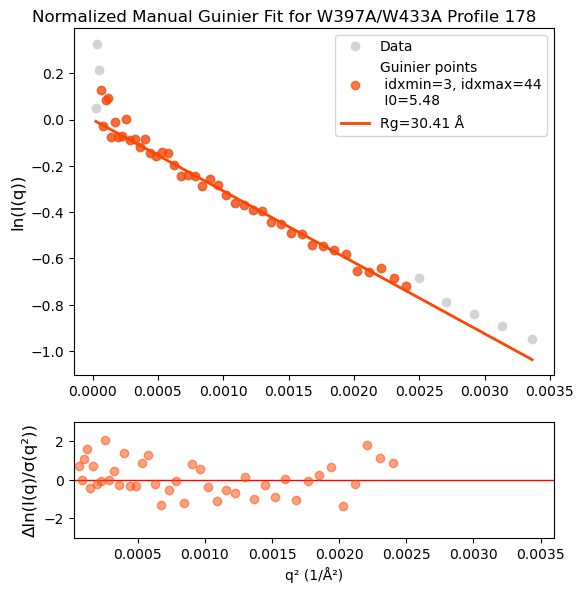

In [111]:
# Normalized Guinier Fit for Individual Profiles
for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
        idx_min = 0
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"
        idx_min = 3
        idx_max = 44

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
        r_sq) = raw.guinier_fit(profile, idx_min,idx_max)
        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()


    # Set up the plot
    fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(hspace=0.2)  # Increase vertical space between subplots
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)

    # Square the q values and take the natural logarithm of the intensity
    q_sq = q**2
    i_ln = np.log(intensity/i0)
    qmin_sq = qmin**2
    qmax_sq = qmax**2

    # plot 0:50 data points for context
    axs[0].plot(q_sq[0:50], i_ln[0:50], marker='o',
            linestyle='None', color='lightgray', label='Data')
    axs[0].set_ylabel('ln(I(q))', fontsize=12)

    # Plot the AutoGuinier fit data points
    mask = (q_sq >= qmin_sq) & (q_sq <= qmax_sq)
    axs[0].plot(q_sq[mask], i_ln[mask], marker='o', linestyle='None',
                label=f'Guinier points\n idxmin={idx_min}, idxmax={idx_max}\n I0={i0:.2f}', 
                color=color, alpha=0.7)

    # Line for the Guinier fit
    # optional: fit a straight line to the selected Guinier points
    if np.count_nonzero(mask) >= 2:
    #Get fit r squared:
        x = np.square(q[idx_min:idx_max+1])
        y = np.log(intensity[idx_min:idx_max+1]/i0)
        sigma = error[idx_min:idx_max+1] / intensity[idx_min:idx_max+1]  # propagate error to ln(I)
        
        a, b, cov_a, cov_b = SASCalc.weighted_lin_reg(x, y, sigma)

        y_fit = SASCalc.linear_func(x, a, b)
        y_line= SASCalc.linear_func(q_sq[0:50], a, b)
        
        gui_err = y - y_fit
        residuals = gui_err / sigma  # weighted residuals
        
        # Plot line of best fit
        axs[0].plot(q_sq[0:50], y_line, '-', label=f'Rg={rg:.2f} Å', 
                color=color, alpha=1, linewidth=2.0, zorder=100)
        axs[0].legend()

        
        # Plot residuals in second subplot
        axs[1].plot(x, residuals, marker='o', linestyle='None', color=color, alpha=0.5)
        
        # Set up labels for residuals subplot
        axs[1].axhline(y=0, color='red', linewidth=1, zorder=0)
        axs[1].set_ylabel('Δln(I(q)/σ(q²))', fontsize=12)
        axs[1].tick_params(axis='both', labelsize=10)
        axs[1].set_xlim(q_sq[0], q_sq[50])  # Set x-axis limits for residuals plot
        axs[1].set_ylim(-3, 3)  # Set y-axis limits for residuals plot

    # Plot Specifications
    plt.xlabel('q² (1/Å²)')
    plt.suptitle(f'Normalized Manual Guinier Fit for {title}')
    plt.show()


## Dimensionless Kratky Plots of Individual Profiles


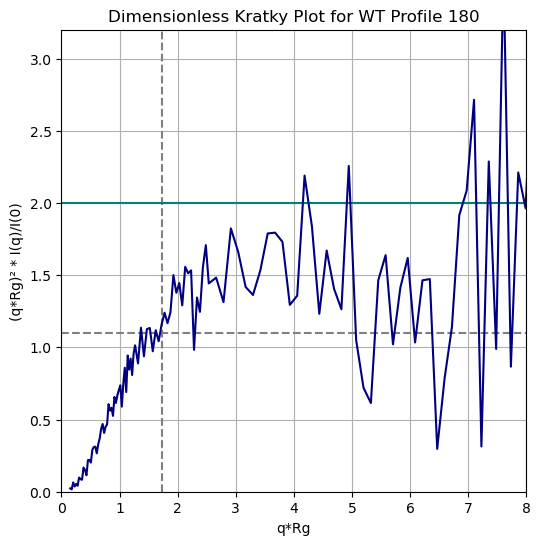

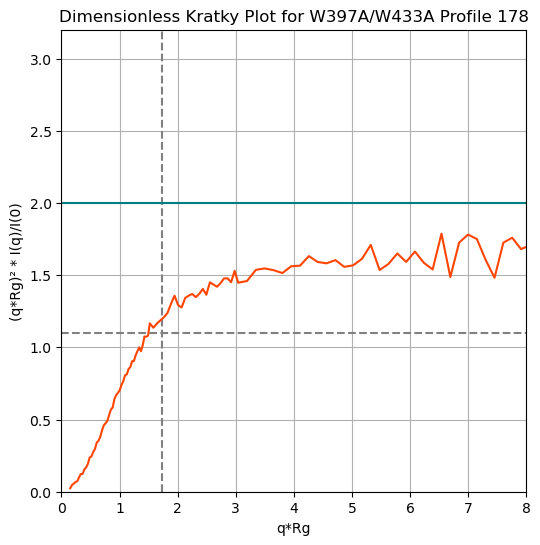

In [113]:
# Dimensionless Kratky Plot for Individual Profiles
for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
        r_sq) = raw.guinier_fit(profile, idx_min,idx_max)
        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()
    # Plot the q and intensity data from first sub-profile as Guinier plot (ln(I) vs q^2)

    # Calculate Kratky parameters
    xkrat = q * rg 
    ykrat = (xkrat ** 2 * intensity) / i0  # (q*rg)^2 * intensity / i0

    # Set up plot
    plt.figure(figsize=(6,6))        
    plt.xlabel('q*Rg')
    plt.ylabel('(q*Rg)² * I(q)/I(0)')

    plt.axvline(x=1.73, color='grey', linestyle='--')
    plt.axhline(y=1.1, color='grey', linestyle='--', label='1.1')
    plt.axhline(y=2, color='teal', linestyle='-') 
    plt.grid(True)
    plt.xlim(0, 8)
    plt.ylim(0, 3.2) 

    # Plot Kratky curve
    plt.plot(xkrat, ykrat, linestyle='-', color=color, label='Kratky plot')
    plt.title(f'Dimensionless Kratky Plot for {title}')

    plt.show()


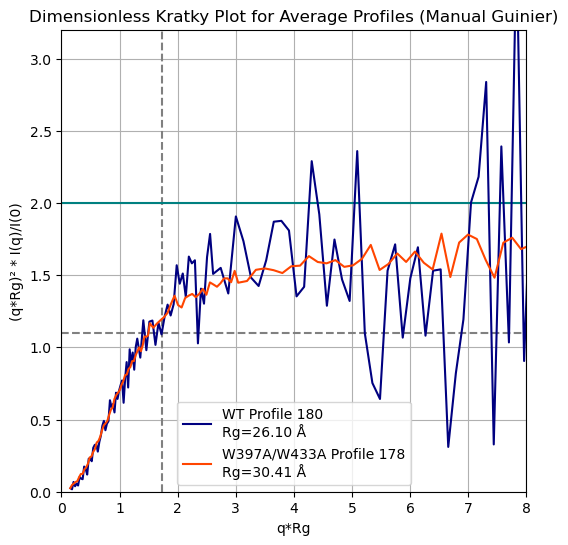

In [117]:
# Dimensionless Kratky Plot for Individual Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q*Rg')
plt.ylabel('(q*Rg)² * I(q)/I(0)')

plt.axvline(x=1.73, color='grey', linestyle='--')
plt.axhline(y=1.1, color='grey', linestyle='--')
plt.axhline(y=2, color='teal', linestyle='-') 
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 3.2) 
plt.title(f'Dimensionless Kratky Plot for Average Profiles (Manual Guinier)')

for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
        idx_min = 0
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"
        idx_min = 3
        idx_max = 44

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, 
        r_sq) = raw.guinier_fit(profile, idx_min,idx_max)
        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()
    # Plot the q and intensity data from first sub-profile as Guinier plot (ln(I) vs q^2)

    # Calculate Kratky parameters
    xkrat = q * rg 
    ykrat = (xkrat ** 2 * intensity) / i0  # (q*rg)^2 * intensity / i0


    # Plot Kratky curve
    plt.plot(xkrat, ykrat, linestyle='-', color=color, label=f'{title}\nRg={rg:.2f} Å')
    plt.legend()


plt.show()


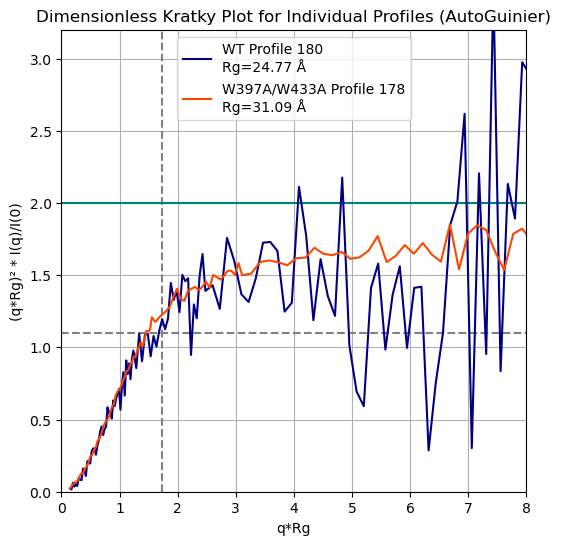

In [116]:
# Dimensionless Kratky Plot for Individual Profiles
# Set up plot
plt.figure(figsize=(6,6))        
plt.xlabel('q*Rg')
plt.ylabel('(q*Rg)² * I(q)/I(0)')

plt.axvline(x=1.73, color='grey', linestyle='--')
plt.axhline(y=1.1, color='grey', linestyle='--')
plt.axhline(y=2, color='teal', linestyle='-') 
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 3.2) 
plt.title(f'Dimensionless Kratky Plot for Individual Profiles (AutoGuinier)')

for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
        idx_min = 0
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"
        idx_min = 3
        idx_max = 44

    (rg, i0, rg_err, i0_err, qmin, qmax, qrg_min, qrg_max, idx_min, idx_max,
        r_sq) = raw.auto_guinier(profile, settings=my_settings)

        

    q = profile.getQ()
    intensity = profile.getI()
    error = profile.getErr()
    # Plot the q and intensity data from first sub-profile as Guinier plot (ln(I) vs q^2)

    # Calculate Kratky parameters
    xkrat = q * rg 
    ykrat = (xkrat ** 2 * intensity) / i0  # (q*rg)^2 * intensity / i0


    # Plot Kratky curve
    plt.plot(xkrat, ykrat, linestyle='-', color=color, label=f'{title}\nRg={rg:.2f} Å')
    plt.legend()


plt.show()


## P(r) Function and Plot of Individual Profiles

/opt/anaconda3/envs/RAW/lib/python3.14/site-packages/bioxtasraw/BIFT.py:334: RuntimeWarning: invalid value encountered in divide
  sinc_qr = np.where(qr==0, 1, np.sin(qr)/qr)


Auto-determined Dmax for WT Profile 180: 86.00 Å
GNOM fit results for Dmax=86 Å:
Dmax: 86.00 Å
Rg: 26.850 ± 0.552 Å
i0: 0.647


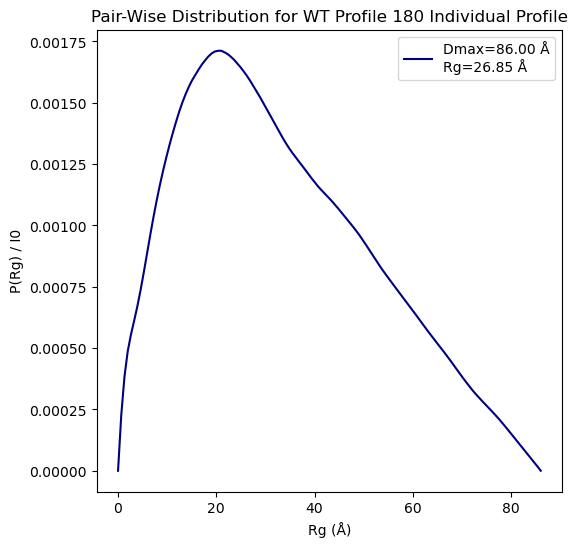

Auto-determined Dmax for W397A/W433A Profile 178: -1.00 Å


/opt/anaconda3/envs/RAW/lib/python3.14/site-packages/bioxtasraw/SASCalc.py:373: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  """Calculates the volume of correlation as the ratio of i0 to $\int q*I dq$


GNOMError: "GNOM failed to run with the following error:\nexpected value greater or equal 0. for option 'rmax', got '-1'"

In [118]:
# GNOM Analysis for Individual Profiles
for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
        idx_min = 3
        idx_max = 45
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"
        idx_min = 3
        idx_max = 41

    dmax = raw.auto_dmax(profile)
    print(f"Auto-determined Dmax for {title}: {dmax:.2f} Å")

    (gnom_ift, gnom_dmax, gnom_rg, gnom_i0, gnom_rg_err,
    gnom_i0_err, gnom_total_est, gnom_chi_sq, gnom_alpha,
    gnom_quality) = raw.gnom(profile, dmax)

    print(f"GNOM fit results for Dmax={dmax} Å:")
    print(f"Dmax: {gnom_dmax:.2f} Å")
    print(f"Rg: {gnom_rg:.3f} ± {gnom_rg_err:.3f} Å")


    iftm = gnom_ift

    i0 = float(iftm.getParameter('i0'))
    print(f"i0: {i0:.3f}")

    # Set up plot
    plt.figure(figsize=(6,6))        
    plt.xlabel('Rg (Å)')
    plt.ylabel('P(Rg) / I0')

    plt.plot(iftm.r, iftm.p/i0, color=color, label=f'Dmax={dmax:.2f} Å\nRg={gnom_rg:.2f} Å')
    plt.legend()


    # Plot Pair-Wise Distribution
    plt.title(f'Pair-Wise Distribution for {title} Individual Profile')

    plt.show()


GNOM fit results for Dmax=110 Å:
Dmax: 110.00 Å
Rg: 28.870 ± 2.179 Å
i0: 0.686


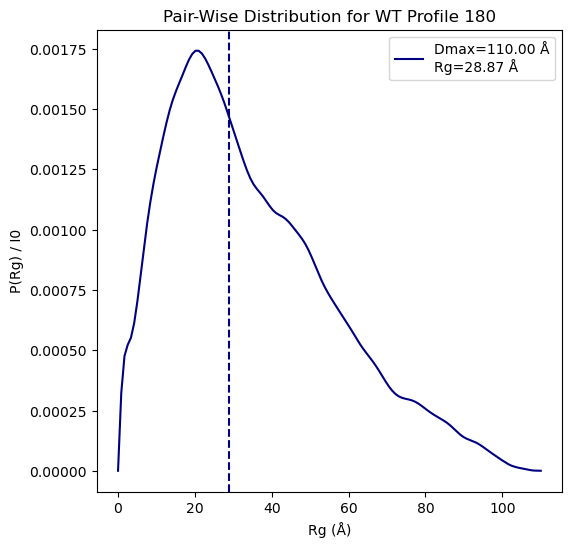

GNOM fit results for Dmax=139 Å:
Dmax: 139.00 Å
Rg: 33.570 ± 1.306 Å
i0: 5.653


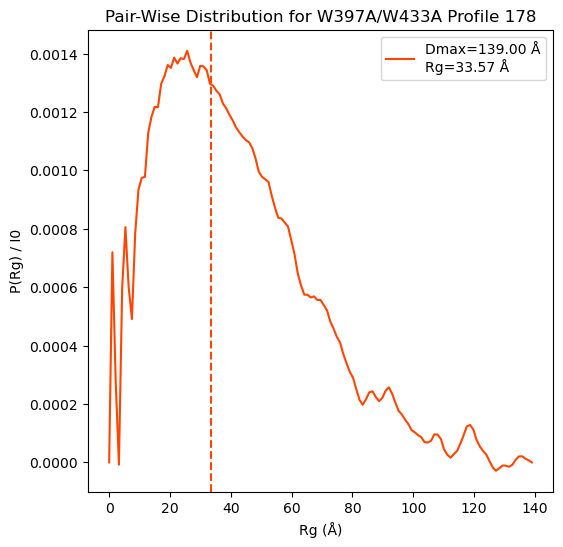

In [127]:
# GNOM Analysis for Average Profiles
for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
        dmax = 110
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"
        dmax = 139


    (gnom_ift, gnom_dmax, gnom_rg, gnom_i0, gnom_rg_err,
    gnom_i0_err, gnom_total_est, gnom_chi_sq, gnom_alpha,
    gnom_quality) = raw.gnom(profile, dmax)

    print(f"GNOM fit results for Dmax={dmax} Å:")
    print(f"Dmax: {gnom_dmax:.2f} Å")
    print(f"Rg: {gnom_rg:.3f} ± {gnom_rg_err:.3f} Å")

    iftm = gnom_ift

    i0 = float(iftm.getParameter('i0'))
    print(f"i0: {i0:.3f}")

    # Set up plot
    plt.figure(figsize=(6,6))        
    plt.xlabel('Rg (Å)')
    plt.ylabel('P(Rg) / I0')

    plt.plot(iftm.r, iftm.p/i0, color=color, label=f'Dmax={dmax:.2f} Å\nRg={gnom_rg:.2f} Å')
    plt.axvline(x=gnom_rg, color=color, linestyle='--')
    plt.legend()


    # Plot Pair-Wise Distribution
    plt.title(f'Pair-Wise Distribution for {title}')

    plt.show()


GNOM fit results for Dmax=110 Å:
Dmax: 110.00 Å
Rg: 28.870 ± 2.270 Å
gnom_chi_sq: 0.424
i0: 0.686
GNOM fit results for Dmax=139 Å:
Dmax: 139.00 Å
Rg: 33.570 ± 1.115 Å
gnom_chi_sq: 0.435
i0: 5.653


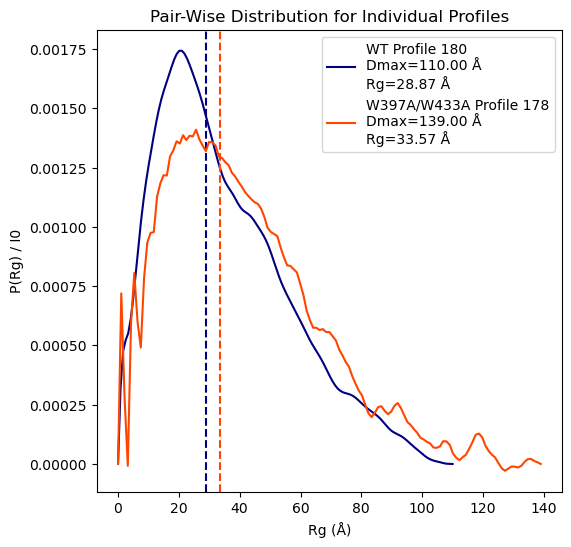

In [125]:
plt.figure(figsize=(6,6))        
plt.xlabel('Rg (Å)')
plt.ylabel('P(Rg) / I0')

# Dimensionless Kratky Plot for Average Profiles
for label, profile in profiles_of_interest.items():
    if label == "WT_092025":
        color = colorWT
        title = f"WT Profile {WT_frame_number}"
        dmax = 110
    elif label == "AA_052026":
        color = colorAA
        title = f"W397A/W433A Profile {AA_frame_number}"
        dmax = 139


    (gnom_ift, gnom_dmax, gnom_rg, gnom_i0, gnom_rg_err,
    gnom_i0_err, gnom_total_est, gnom_chi_sq, gnom_alpha,
    gnom_quality) = raw.gnom(profile, dmax)

    print(f"GNOM fit results for Dmax={dmax} Å:")
    print(f"Dmax: {gnom_dmax:.2f} Å")
    print(f"Rg: {gnom_rg:.3f} ± {gnom_rg_err:.3f} Å")
    # print(f"gnom_quality: {gnom_quality}")
    print(f"gnom_chi_sq: {gnom_chi_sq:.3f}")

    iftm = gnom_ift

    i0 = float(iftm.getParameter('i0'))
    print(f"i0: {i0:.3f}")

    # Set up plot


    plt.plot(iftm.r, iftm.p/i0, color=color, 
             label=f'{title}\nDmax={dmax:.2f} Å\nRg={gnom_rg:.2f} Å')
    plt.axvline(x=gnom_rg, color=color, linestyle='--')

    


    # Plot Pair-Wise Distribution
plt.title(f'Pair-Wise Distribution for Individual Profiles')
plt.legend()
plt.show()
